<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day07_practice1_%ED%95%A9%EC%84%B1%EA%B3%B1_%ED%95%B4%EB%B6%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 합성곱 해부 - 필터가 이미지를 읽는 법
# MLP는 픽셀 위치를 모른다 -> 합성곱은  픽셀끼리 묶어서 본다.

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [3]:
# [셀 1] 합성곱 손계산 - 4x4 이미지에 2x2 필터
# 합성곱 = 필터로 이미지 위에서 슬라이딩하며, 겹친 자리끼리 곱해 더한 값을 찍는 것

img = torch.tensor([[1.,2.,3.,0.],
                    [0.,1.,2.,3.],
                    [3.,0.,1.,2.],
                    [2.,3.,0.,1.]])
filt = torch.tensor([[1.,0.],
                     [0.,1.]])
print("왼쪽 위 한 칸 손계산:", (img[0:2,0:2] * filt).sum().item())

out_hand = torch.zeros(3,3) # 결과(특징맵)를  담을 3x3 빈 텐서
for i in range(3): # 행
  for j in range(3): # 열
    out_hand[i,j] = (img[i:i+2,j:j+2] * filt).sum()
print("손계산 특징맵(3x3):\n", out_hand)

왼쪽 위 한 칸 손계산: 2.0
손계산 특징맵(3x3):
 tensor([[2., 4., 6.],
        [0., 2., 4.],
        [6., 0., 2.]])


In [4]:
# [셀 2] nn.Conv2d로 같은 계산
conv = nn.Conv2d(in_channels=1, out_channels=1, # 입력 채널1(흑백), 출력 채널1(피처맵)

                 kernel_size=2, bias=False) # 커널 2 x 2
with torch.no_grad():     # 가중치를 직접 바꿀 땐 기울기 추적 끔
  conv.weight[0,0] = filt # Conv2d 의 필터 자리에 우리 filt를 강제로 심음. 실제로는 역전파가 "어떤 무늬를 감지할지"를 데이터로부터 스스로 학습
out_torch = conv(img.reshape(1, 1, 4, 4)) # 파이토치 이미지 표준 모양 = (B, C, H, W), 입력을 (배치1, 채널1, 높이4, 너비4)
print("\nConv2d 결과 : \n", out_torch.squeeze()) # 크기 1 축 제거해 3x3으로 보기 좋게
assert torch.allclose(out_hand, out_torch.squeeze()), "불일치"


Conv2d 결과 : 
 tensor([[2., 4., 6.],
        [0., 2., 4.],
        [6., 0., 2.]], grad_fn=<SqueezeBackward0>)


100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 57.0MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.18MB/s]



 사진: T-shirt/top torch.Size([1, 28, 28])


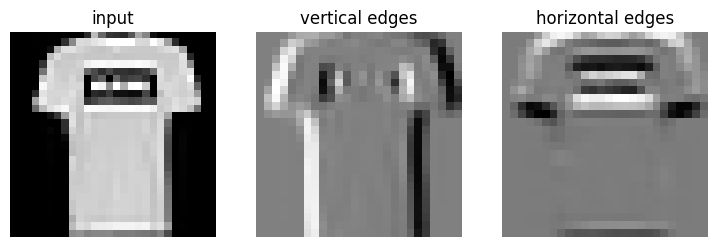

In [5]:
# [셀 3] 유명한 엣지 필터를 진짜 옷 사진에 적용 - 특징맵 시각화
from torchvision import datasets, transforms

def load_fmnist(root="./data"):
  return datasets.FashionMNIST(root=root, download=True, transform=transforms.ToTensor())

data = load_fmnist()
img, label = data[1] # 두 번째 샘플 한 장
print("\n 사진:", data.classes[label], img.shape)
vertical = torch.tensor([[[-1.,0.,1.], # 세로 엣지 감지 필터(Sobel):
                           [-2.,0.,2.],
                           [-1.,0.,1.]]])
horizontal = vertical.transpose(1,2) # 가로 엣지 필터 = 세로 필터를 전치
conv3 = nn.Conv2d(1, 2, kernel_size=3, bias=False) #입력1채널 -> 출력2채널
                                                   # img(1, 28, 28)
with torch.no_grad():
  conv3.weight[0] = vertical          # 0번 필터
  conv3.weight[1] = horizontal        # 1번 필터
fmap = conv3(img.unsqueeze(0)).squeeze(0) # unsqueeze(0): 배치 추가 -> (1,1,28,28), 통과 후 squeeze: 배치 없애고 -> (2,26,26)

fig, axes = plt.subplots(1,3, figsize=(9,3))
for ax, im, title in zip(axes,
                         [img[0], fmap[0].detach(),fmap[1].detach()], # 원본, 세로맵, 가로맵 #.detach() gradient 추적이 끊긴 복사본
                         ["input", "vertical edges","horizontal edges"]):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.show()

In [6]:
# [셀 4] 풀링 - 특징맵을 요약해서 줄인다
# 풀링 효과:  크기 절반 -> 계산량 1/4, 위치 관용(대략 이 근처), 학습 파라미터 0개(그냥 최댓값 고르기)
x = torch.tensor([[1.,3.,2.,4.],
                  [5.,6.,1.,2.],
                  [7.,2.,9.,3],
                  [1.,4.,2.,8.]])
pool = nn.MaxPool2d(kernel_size=2)
out = pool(x.reshape(1,1,4,4)).squeeze()
print("\nMaxPool2d 결과:\n", out)
assert torch.equal(out, torch.tensor([[6.,4.],[7.,9.]])) # 손계산과 일치


MaxPool2d 결과:
 tensor([[6., 4.],
        [7., 9.]])


In [8]:
# [셀 5] 출력 크기 공식 - shape 예측 능력
# 출력 크기 - ((입력 - 필터 + 2 × 패딩) / 스트라이드) + 1
cases = [
    ("28, k3, p0, s1", nn.Conv2d(1,8,3)),
    ("28, k3, p1, s1", nn.Conv2d(1,8,3, padding=1)), # 패딩1 -> 크기 유지
    ("28, k3, p1, s2", nn.Conv2d(1,8,3, padding=1, stride=2)), # 스트라이드2 -> 출력 크기 절반
]
x = torch.randn(1, 1, 28, 28) # PyTorch의 4차원 이미지 텐서는 (N, C, H, W)
print()
for name, layer in cases:
  print(f"입력 {name} -> 출력 {tuple(layer(x).shape)}")


입력 28, k3, p0, s1 -> 출력 (1, 8, 26, 26)
입력 28, k3, p1, s1 -> 출력 (1, 8, 28, 28)
입력 28, k3, p1, s2 -> 출력 (1, 8, 14, 14)
